# 2D organoid segmentation with nnU-Net v2

Brightfield organoid (acinus) segmentation trained directly with a native **2D nnU-Net v2**, adapted from the 3D vasculature pipeline in `vascumap/vascumap_model_retraining/segmentation_3d/straight_to_segmentation.ipynb`.

**Adaptation to 2D / this dataset**
- Input: single-channel brightfield `*.tiff` (2160x2160, uint16).
- Labels: instance masks (`*.tif`, integer ids per organoid) are **binarised** to a single `organoid` foreground class - nnU-Net does semantic, not instance, segmentation.
- No ignore label / device rectangle / organoid sidecars: those were vascumap-specific. Here the whole frame is trainable (`background=0`, `organoid=1`).
- Each 2D image is stored as a `(1, Y, X)` NIfTI (singleton z), which nnU-Net auto-detects as 2D.
- nnU-Net directories live **outside** Dropbox so preprocessed/results are not synced.

Run this notebook with the `vascumap_nnunet` kernel.

In [1]:
import os, json, csv, subprocess
from pathlib import Path
import numpy as np
import tifffile
import SimpleITK as sitk
import torch
import matplotlib.pyplot as plt

print('torch', torch.__version__, '| cuda', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

torch 2.11.0+cu128 | cuda True | NVIDIA GeForce RTX 3080


In [2]:
# ---- Data (matched brightfield / instance-label pairs) ----
IMAGES_DIR = Path('C:/Users/isobe/The University of Manchester Dropbox/Isobel Taylor-Hearn/marta_labels/tiff')
LABELS_DIR = Path('C:/Users/isobe/The University of Manchester Dropbox/Isobel Taylor-Hearn/marta_labels/labels')
IMAGE_GLOB = '*.tiff'
LABEL_EXT  = '.tif'                      # labels share the image stem but use .tif

# ---- nnU-Net config (kept OFF Dropbox so preprocessed data is not synced) ----
NNUNET_BASE  = Path.home() / 'nnUNet'
DATASET_ID   = 1
DATASET_NAME = f'Dataset{DATASET_ID:03d}_Organoid'
LABELS        = {'background': 0, 'organoid': 1}
CHANNEL_NAMES = {0: 'brightfield'}
SPACING_XY    = (1.0, 1.0)              # no header pixel size -> unit isotropic spacing
CONFIG     = '2d'
FOLD       = 'all'                      # train on all cases; use a 0-4 fold for a CV Dice curve
TRAINER    = 'nnUNetTrainer_250epochs_preview'  # 250-epoch trainer that also saves preview PNGs
CHECKPOINT = 'checkpoint_best.pth'

# Training preview PNGs (input / ground truth / prediction) saved next to the images and labels.
PREVIEW_DIR   = IMAGES_DIR.parent / 'training_previews'
PREVIEW_EVERY = 10                       # save one preview every N epochs

NNUNET_RAW          = NNUNET_BASE / 'nnUNet_raw'
NNUNET_PREPROCESSED = NNUNET_BASE / 'nnUNet_preprocessed'
NNUNET_RESULTS      = NNUNET_BASE / 'nnUNet_results'
for d in (NNUNET_RAW, NNUNET_PREPROCESSED, NNUNET_RESULTS):
    d.mkdir(parents=True, exist_ok=True)
os.environ['nnUNet_raw']          = str(NNUNET_RAW)
os.environ['nnUNet_preprocessed'] = str(NNUNET_PREPROCESSED)
os.environ['nnUNet_results']      = str(NNUNET_RESULTS)
os.environ.pop('nnUNet_n_proc_DA', None)   # clear stale value (0 crashes plan_and_preprocess)

RAW_DS = NNUNET_RAW / DATASET_NAME
(RAW_DS / 'imagesTr').mkdir(parents=True, exist_ok=True)
(RAW_DS / 'labelsTr').mkdir(parents=True, exist_ok=True)
PROVENANCE = RAW_DS / 'provenance.csv'
print('images :', IMAGES_DIR)
print('labels :', LABELS_DIR)
print('raw ds :', RAW_DS)

images : C:\Users\isobe\The University of Manchester Dropbox\Isobel Taylor-Hearn\marta_labels\tiff
labels : C:\Users\isobe\The University of Manchester Dropbox\Isobel Taylor-Hearn\marta_labels\labels
raw ds : C:\Users\isobe\nnUNet\nnUNet_raw\Dataset001_Organoid


In [3]:
# ########## SANITY CHECK!!!!!!!
# images = sorted(IMAGES_DIR.glob(IMAGE_GLOB))
# labels = sorted(LABELS_DIR.glob(f'*{LABEL_EXT}'))
# print(len(images), 'images,', len(labels), 'labels')
# for i in range(141):
#     fig, ax = plt.subplots(ncols = 2)
#     ax[0].imshow(tifffile.imread(images[i]), cmap = 'gray')
#     ax[1].imshow(tifffile.imread(labels[i]), cmap = 'gray')
#     plt.suptitle(f"Image: {images[i].name} ")
#     for a in ax:
#         a.axis('off')
#     plt.show()

In [4]:
def load_pair(img_path):
    """Brightfield (Y,X float32) + binarised organoid mask (Y,X uint8) from a matched pair."""
    bf = np.asarray(tifffile.imread(str(img_path))).astype(np.float32)
    lab_path = LABELS_DIR / (img_path.stem + LABEL_EXT)
    inst = np.asarray(tifffile.imread(str(lab_path)))
    if bf.shape != inst.shape:
        raise ValueError(f'{img_path.name}: image {bf.shape} vs label {inst.shape} shape mismatch')
    mask = (inst > 0).astype(np.uint8)          # instance ids -> single organoid foreground class
    return bf, mask

def write_nii_2d(arr_yx, path, is_label, spacing_xy=SPACING_XY):
    """Write a 2D array as a (1,Y,X) NIfTI; the singleton z makes nnU-Net treat it as 2D."""
    vol = arr_yx[None]
    img = sitk.GetImageFromArray(vol.astype(np.uint8 if is_label else np.float32))
    img.SetSpacing((float(spacing_xy[0]), float(spacing_xy[1]), 999.0))   # sitk order (x,y,z)
    sitk.WriteImage(img, str(path))

## Convert the pairs to nnU-Net raw format

In [5]:
def build_dataset(img_paths):
    rows = []
    for k, ip in enumerate(img_paths):
        case = f'organoid_{k:03d}'
        bf, mask = load_pair(ip)
        write_nii_2d(bf,   RAW_DS / 'imagesTr' / f'{case}_0000.nii.gz', is_label=False)
        write_nii_2d(mask, RAW_DS / 'labelsTr' / f'{case}.nii.gz',      is_label=True)
        frac = 100.0 * float(mask.mean())
        rows.append((case, ip.stem, round(frac, 2)))
        print(f'  {case}  {ip.stem[:44]:44s}  organoid={frac:5.2f}%')
    with open(PROVENANCE, 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['case', 'source_stem', 'organoid_pct']); w.writerows(rows)
    return rows

img_paths = sorted(IMAGES_DIR.glob(IMAGE_GLOB))
missing = [p.name for p in img_paths if not (LABELS_DIR / (p.stem + LABEL_EXT)).exists()]
print(f'{len(img_paths)} images found; {len(missing)} without a matching label', missing[:5])
rows = build_dataset(img_paths)
n_train = len(list((RAW_DS / 'labelsTr').glob('*.nii.gz')))

from nnunetv2.dataset_conversion.generate_dataset_json import generate_dataset_json
generate_dataset_json(str(RAW_DS), channel_names=CHANNEL_NAMES, labels=LABELS,
                      num_training_cases=n_train, file_ending='.nii.gz', dataset_name=DATASET_NAME)
print(f'dataset.json written with {n_train} training cases')

167 images found; 0 without a matching label []
  organoid_000  r01c02f01p01-ch1sk1fk1fl1                     organoid= 0.00%
  organoid_001  r01c02f06p01-ch1sk1fk1fl1                     organoid= 0.17%
  organoid_002  r01c02f08p01-ch1sk1fk1fl1                     organoid= 0.00%
  organoid_003  r01c02f09p01-ch1sk1fk1fl1                     organoid= 0.00%
  organoid_004  r01c02f19p01-ch1sk1fk1fl1                     organoid= 1.04%
  organoid_005  r01c02f19p01-ch2sk1fk1fl1                     organoid= 1.40%
  organoid_006  r01c02f23p01-ch2sk1fk1fl1                     organoid= 0.27%
  organoid_007  r01c02f24p01-ch2sk1fk1fl1                     organoid= 0.33%
  organoid_008  r01c02f25p01-ch1sk1fk1fl1                     organoid= 0.02%
  organoid_009  r01c02f26p01-ch2sk1fk1fl1                     organoid= 1.88%
  organoid_010  r01c02f27p01-ch2sk1fk1fl1                     organoid= 0.36%
  organoid_011  r01c02f31p01-ch2sk1fk1fl1                     organoid= 0.78%
  organoid_012  

## Plan, preprocess, train

In [6]:
def run(cmd, da_workers=None):
    """Stream an nnU-Net CLI command. da_workers=0 -> single-threaded augmentation (Windows)."""
    env = os.environ.copy()
    env['PYTHONUNBUFFERED'] = '1'
    if da_workers is not None:
        env['nnUNet_n_proc_DA'] = str(da_workers)
        env.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
        env['OMP_NUM_THREADS'] = '1'
        env['MKL_NUM_THREADS'] = '1'
    print('>', cmd, flush=True)
    proc = subprocess.Popen(cmd, shell=True, env=env, text=True, bufsize=1,
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    for line in proc.stdout:
        print(line, end='', flush=True)
    if proc.wait() != 0:
        raise subprocess.CalledProcessError(proc.returncode, cmd)

In [7]:
run(f'nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity')

plans = NNUNET_PREPROCESSED / DATASET_NAME / 'nnUNetPlans.json'
if plans.exists():
    cfg = json.loads(plans.read_text())['configurations'].get(CONFIG, {})
    print('target spacing:', cfg.get('spacing'))
    print('patch size    :', cfg.get('patch_size'))
    print('batch size    :', cfg.get('batch_size'))

> nnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity
Fingerprint extraction...
Dataset001_Organoid
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': (np.int64(1280), np.int64(1024)), 'median_image_size_in_voxels': array([2160., 2160.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'resampling_fn_da

In [8]:
# Long-running. da_workers=0 avoids the silently-dying augmentation workers on Windows.
# You can also run this exact command in a `vascumap_nnunet` terminal instead.
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)
os.environ['NNUNET_PREVIEW_DIR']   = str(PREVIEW_DIR)
os.environ['NNUNET_PREVIEW_EVERY'] = str(PREVIEW_EVERY)
run(f'nnUNetv2_train {DATASET_ID} {CONFIG} {FOLD} -tr {TRAINER}', da_workers=0)

> nnUNetv2_train 1 2d all -tr nnUNetTrainer_250epochs_preview

############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-09-02 14:10:53.767347: do_dummy_2d_data_aug: False

This is the configuration used by this training:
Configuration name: 2d
 {'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patc

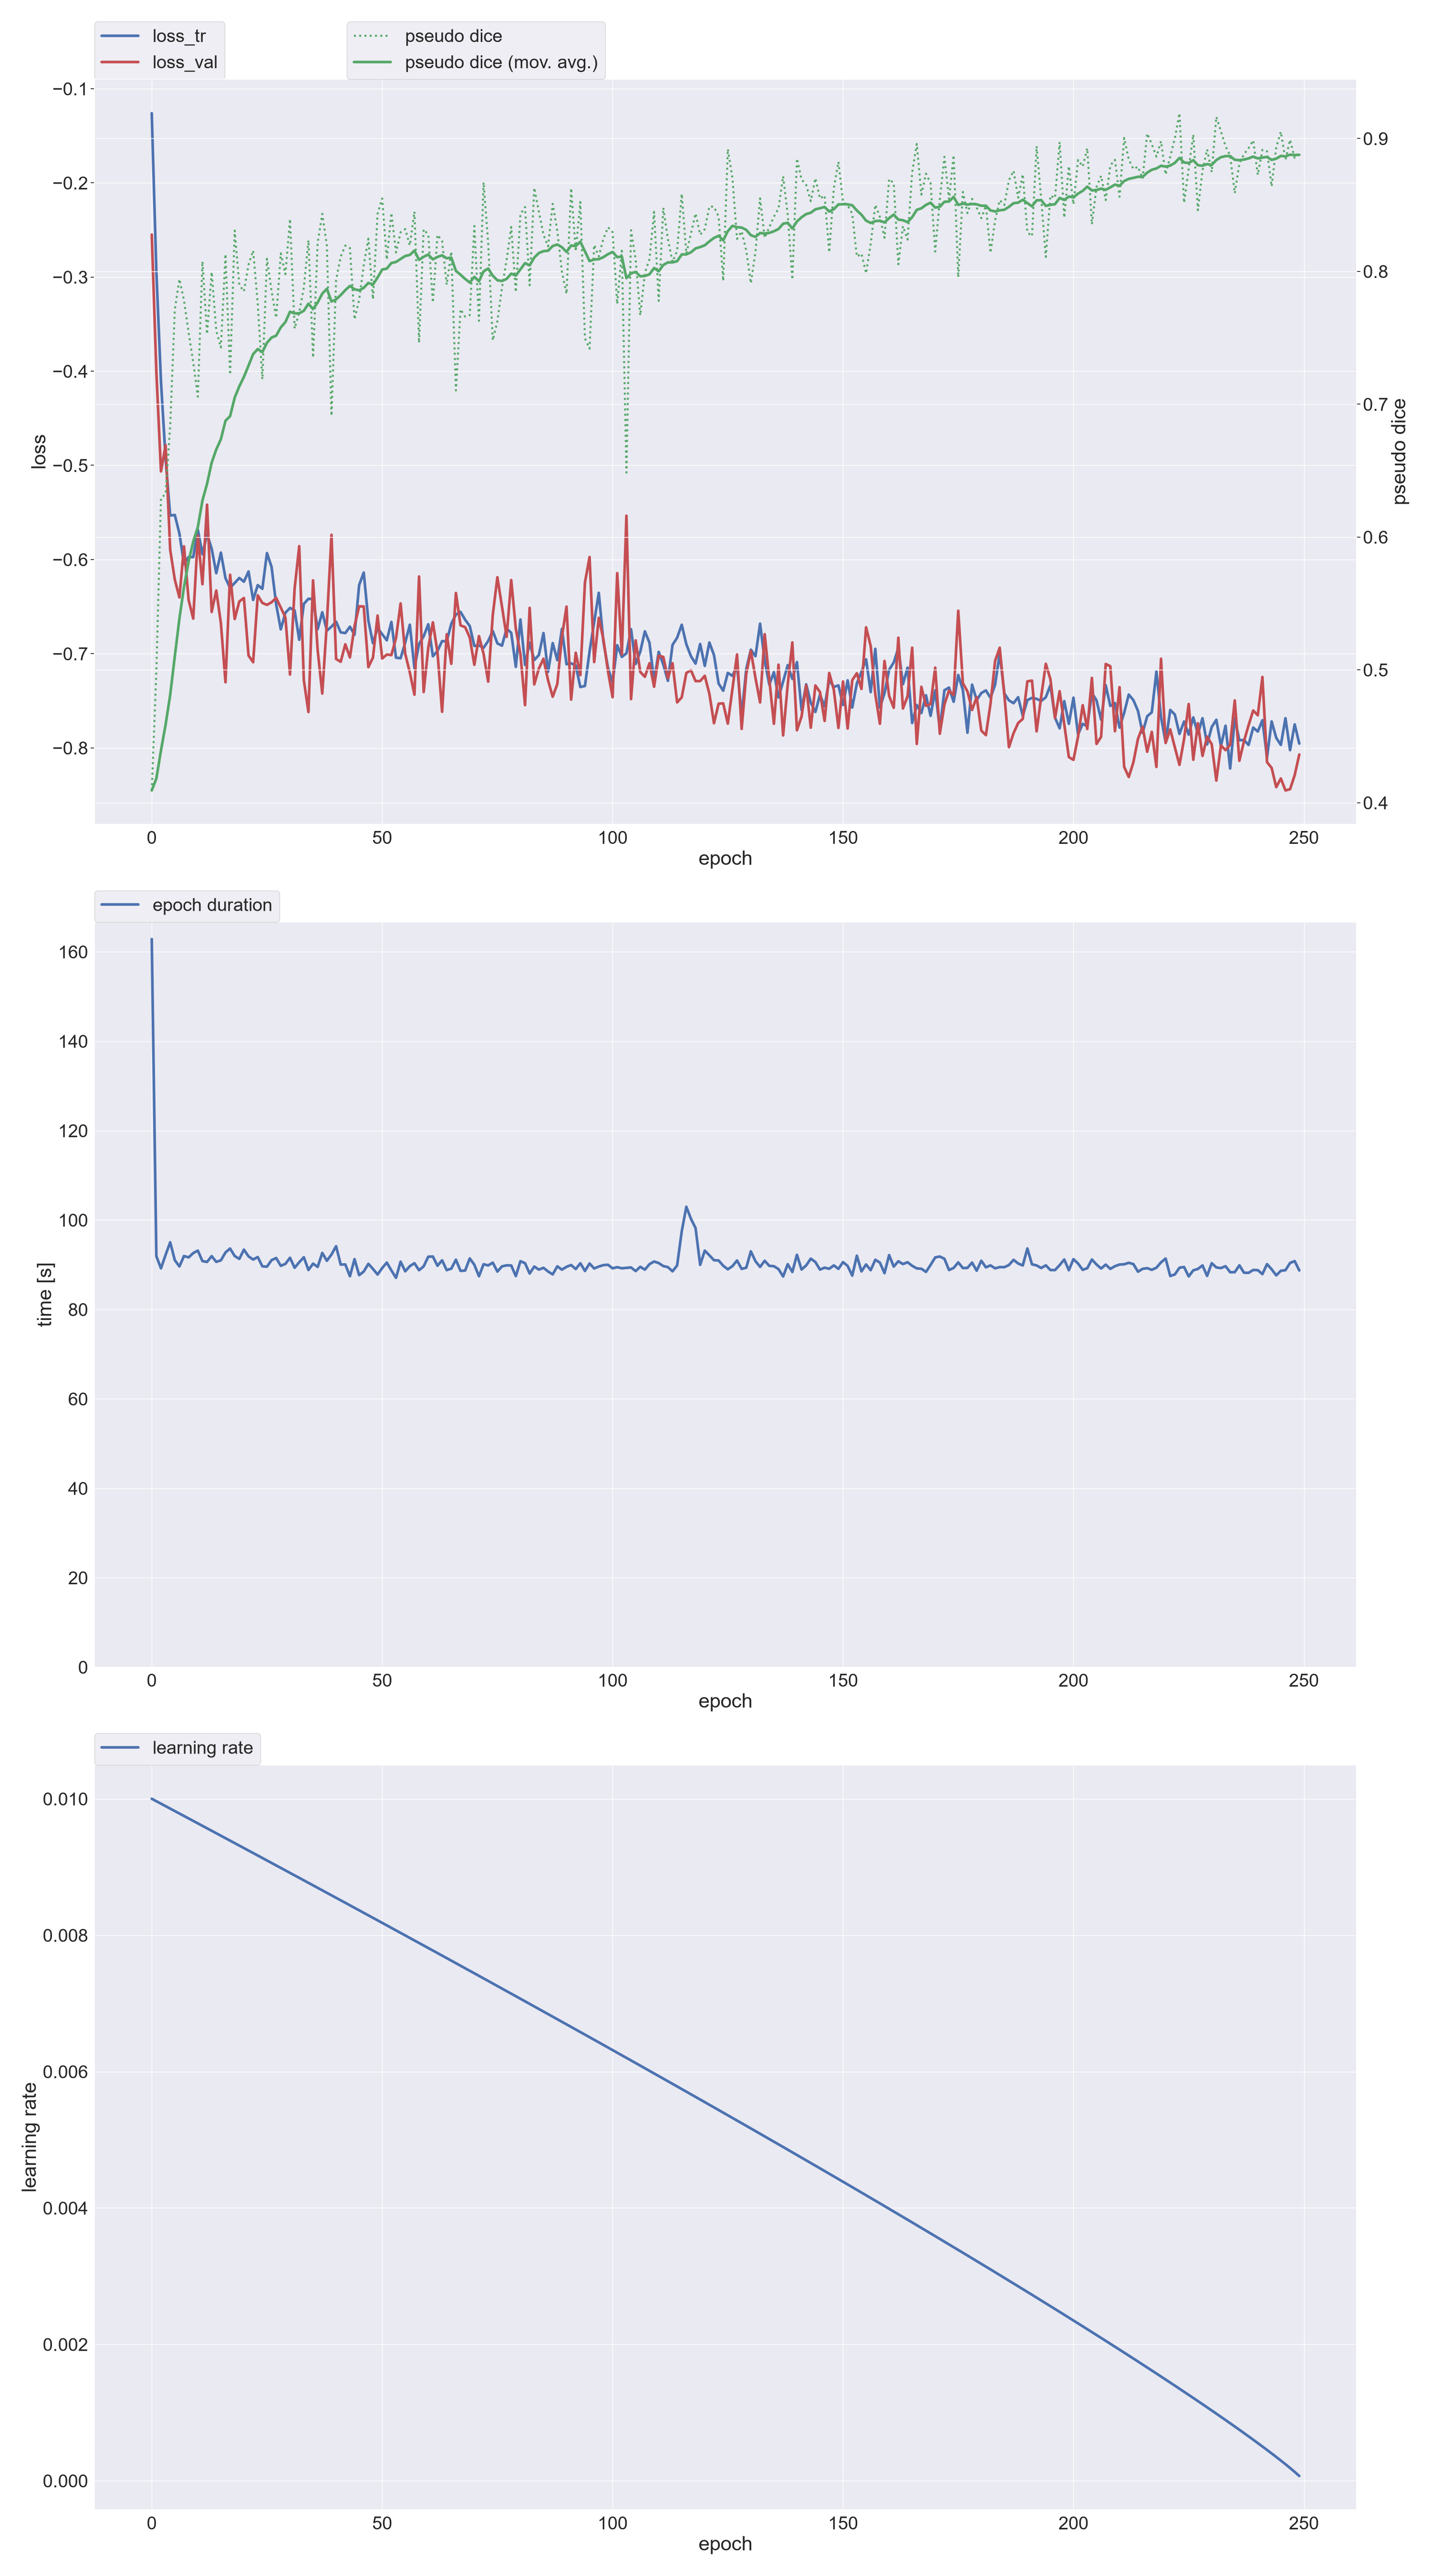

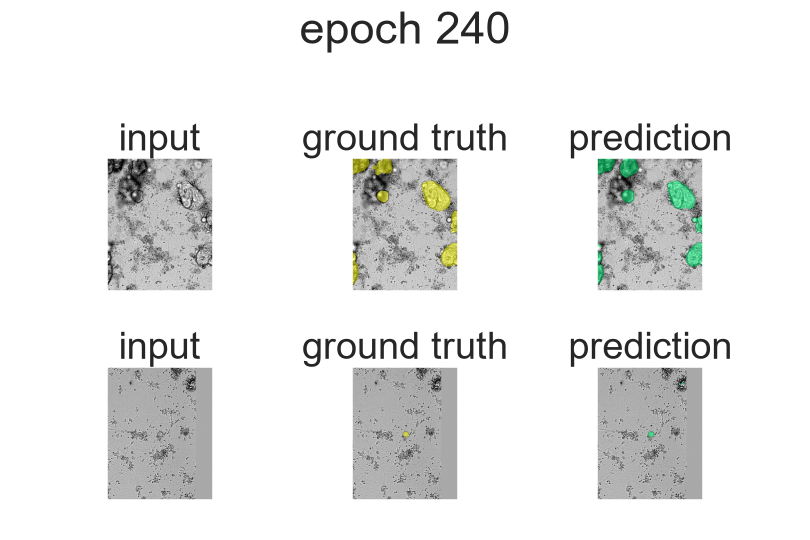

In [9]:
from IPython.display import Image, display
run_dir = NNUNET_RESULTS / DATASET_NAME / f'{TRAINER}__nnUNetPlans__{CONFIG}' / f'fold_{FOLD}'
prog = run_dir / 'progress.png'
display(Image(str(prog))) if prog.exists() else print('no progress.png yet:', run_dir)

# Latest input / ground-truth / prediction preview saved next to the data.
previews = sorted(PREVIEW_DIR.glob('preview_epoch_*.png'))
display(Image(str(previews[-1]))) if previews else print('no preview PNG yet in', PREVIEW_DIR)

## Predict on new brightfield images

Point `PREDICT_SRC` at a folder of new `*.tiff` brightfield frames. Each is staged as a `(1,Y,X)` NIfTI, predicted, and written back out as a binary organoid mask `*.tif`.

In [10]:
# PREDICT_SRC = IMAGES_DIR                       # EDIT: folder of new brightfield *.tiff to segment
# PRED_IN   = NNUNET_BASE / 'predict_in'
# PRED_OUT  = NNUNET_BASE / 'predict_out'
# PRED_TIF  = NNUNET_BASE / 'predict_masks'
# for d in (PRED_IN, PRED_OUT, PRED_TIF):
#     d.mkdir(parents=True, exist_ok=True)

# def segment_images(tifs):
#     tifs = list(tifs); meta = {}
#     for k, tif in enumerate(tifs):
#         bf = np.asarray(tifffile.imread(str(tif))).astype(np.float32)
#         case = f'pred_{k:03d}'
#         write_nii_2d(bf, PRED_IN / f'{case}_0000.nii.gz', is_label=False)
#         meta[case] = tif
#     run(f'nnUNetv2_predict -i {PRED_IN} -o {PRED_OUT} -d {DATASET_ID} -c {CONFIG} '
#         f'-f {FOLD} -tr {TRAINER} -chk {CHECKPOINT}')
#     for case, tif in meta.items():
#         pred = sitk.GetArrayFromImage(sitk.ReadImage(str(PRED_OUT / f'{case}.nii.gz')))
#         mask = (pred[0] == LABELS['organoid']).astype(np.uint8)   # drop singleton z
#         out = PRED_TIF / f'{tif.stem}_mask.tif'
#         tifffile.imwrite(str(out), mask)
#         print('wrote', out.name, '| organoid%=', round(100 * float(mask.mean()), 2))
#     print('masks ->', PRED_TIF)

# predict_tifs = sorted(PREDICT_SRC.glob('*.tiff'))
# print(f'{len(predict_tifs)} images to segment')
# # segment_images(predict_tifs)

In [11]:
# Segment every slice of each time-lapse stack in stack_videos with the best model,
# then save a 2-channel (ch0=brightfield, ch1=organoid label) stack to stack_outputs.
import shutil

STACK_SRC    = Path('C:/Users/isobe/The University of Manchester Dropbox/Isobel Taylor-Hearn/marta_labels/stack_videos')
STACK_OUT    = Path('C:/Users/isobe/The University of Manchester Dropbox/Isobel Taylor-Hearn/marta_labels/stack_outputs')
STACK_IN_NII = NNUNET_BASE / 'stack_in'
STACK_PRED   = NNUNET_BASE / 'stack_pred'
for d in (STACK_IN_NII, STACK_PRED):
    shutil.rmtree(d, ignore_errors=True); d.mkdir(parents=True, exist_ok=True)

def read_stack_bf(path):
    """(Z, Y, X) float32 brightfield from a stacked TIFF; channel 0 if a channel axis exists."""
    arr = np.asarray(tifffile.imread(str(path))).astype(np.float32)
    if arr.ndim == 2:
        arr = arr[None]
    elif arr.ndim == 4:                                   # (Z, C, Y, X) -> channel 0
        arr = np.take(arr, 0, axis=1 if arr.shape[1] <= 4 else 0)
    return arr

# Stage every slice of every stack as an independent 2D case (a single predict call for all).
stack_tifs = sorted(STACK_SRC.rglob('*.tif*'))
counts = {}
for i, p in enumerate(stack_tifs):
    bf = read_stack_bf(p)
    counts[i] = bf.shape[0]
    for z in range(bf.shape[0]):
        write_nii_2d(bf[z], STACK_IN_NII / f'{i:03d}_{z:04d}_0000.nii.gz', is_label=False)
print(f'{len(stack_tifs)} stacks, {sum(counts.values())} slices staged; predicting...')

run(f'nnUNetv2_predict -i {STACK_IN_NII} -o {STACK_PRED} -d {DATASET_ID} -c {CONFIG} '
    f'-f {FOLD} -tr {TRAINER} -chk {CHECKPOINT}')

# Reassemble per stack: ZCYX with ch0=brightfield, ch1=organoid label; mirror sub-folders.
for i, p in enumerate(stack_tifs):
    bf = read_stack_bf(p)
    labels = np.zeros(bf.shape, dtype=np.uint16)
    for z in range(counts[i]):
        pred = sitk.GetArrayFromImage(sitk.ReadImage(str(STACK_PRED / f'{i:03d}_{z:04d}.nii.gz')))
        labels[z] = (pred[0] == LABELS['organoid']).astype(np.uint16)
    stack = np.stack([bf.astype(np.uint16), labels], axis=1)
    rel = p.relative_to(STACK_SRC)
    out = STACK_OUT / rel.with_name(rel.stem + '_labels.tif')
    out.parent.mkdir(parents=True, exist_ok=True)
    tifffile.imwrite(str(out), stack, imagej=True, metadata={'axes': 'ZCYX'})
    print(f'{rel.as_posix()}  ({counts[i]} slices)  organoid%={100 * float(labels.mean()):.2f}  -> {out}')
print('done ->', STACK_OUT)

60 stacks, 935 slices staged; predicting...
> nnUNetv2_predict -i C:\Users\isobe\nnUNet\stack_in -o C:\Users\isobe\nnUNet\stack_pred -d 1 -c 2d -f all -tr nnUNetTrainer_250epochs_preview -chk checkpoint_best.pth

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 935 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 935 cases that I would like to predict

Predicting 000_0000:
perform_everything_on_device: True

100%|██████████| 12/12 [00:10<00:00,  1.14it/s]
sending off prediction to background worker for resampling and export
done with 000_0000

Predicting 000_0001:
perfo